# Results

## 6.1 Low flow climate analysis 

To evaluate low flow conditions, the annual low flow days were calculated for each climate scenario, shown in table 6.1. The future climate scenarios between 2025-2099 show an increase in annual low flow days compared to the observed historical period between 2000-2025. The observed period shows an average of 27 low flow days per year while future periods range from 31 to 49. 

*Table 6.1: Annual mean low flow days during the open water season under climate scenarios in 25 year periods.*

| **Scenario**   | **Observed 2000-2025**  | 2025-2050 | 2050-2075  | 2075-2099 |
|----------------|-------------------------|-----------|------------|-----------|
| SSP126         | 27                      | 36        | 38         | 35        | 
| SSP245         | 27                      | 40        | 38         | 31        |
| SSP370         | 27                      | 34        | 45         | 49        |

Figure 12 shows annual low flow days for the observed period and future climate scenarios. Visually, SSP126 remains relatively stable between 2025-2099, while SSP245 shows a slight decreasing trend. SSp370 shows the clearest increase over time. This is consistent with the forcing data trends shown in Appendix D, where SSP370 shows the strongest increase in temperature and potential evaporation. For SSP245, the increase in precipitation may partly explain the decrease in low flow days between 2075-2099. To evaluate whether the fitted trends in annual low flow days were statistically meaningful, a linear regression was applied for each climate scenario. The p value of the fitted slope was used to test whether the trend was statistically significant using a threshold of 0,05. 

### Startup & Imports

In [3]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.interpolate import interp1d
from scipy.stats import linregress

# Niceties
from rich import print

In [4]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [5]:
# Defining things

basin_size = 132572
q_critical = 500

start_year = 2025
end_year = 2050

In [6]:
# Define only future scenarios
scenarios = ["ssp126", "ssp245", "ssp370"]

# Redefine scenarios to include historical
scenarios_new = ["historical", "ssp126", "ssp245", "ssp370"]

# Attach colours to scenarios to make plotting easier 
colours = {"historical": "tab:blue", "ssp126": "green", "ssp245": "orange", "ssp370": "red"}

# Define periods
periods = [[2025, 2050, 2075],
           [2050, 2075, 2099]]

hist_periods = ([1989], [2014]) 

In [7]:
# Create pathways

def forcing_path_cmip(scenario, start_year, end_year):
    
    forcing_path = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}"
    
    return forcing_path

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [8]:
# Adjust time period

validation_start = f"{start_year}-01-01T00:00:00Z"
validation_end = f"{end_year}-12-31T00:00:00Z"

# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for filling storages
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

In [9]:
# Load in observed discharge data

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

### Model Setup

In [10]:
# Define parameter ensemble

par_ensemble = [
    [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606],
    [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504],
    [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857],
    [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392],
   [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]]


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"]          # Snowmelt factor

In [11]:
# Define initial storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

In [12]:
# Model configuration function

def run_hbv(parameters, initial_storages, forcing):

    # Creating model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Creating config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config)

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m,
        index=time,
        name="Modelled discharge")

    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

In [13]:
# Model running create function

def run_hbv_ensemble(par_ensemble, initial_storages, forcing):

    # Define amount of parameter sets
    N = len(par_ensemble)
    
    # Create dataframe to append data to & add column for observed data
    ensemble_data = pd.DataFrame()

    for i in range(N):

        # print(f"Running parameter set {i+1}/{N}")

        # Run HBV model for the parameter sets 
        simulated = run_hbv(
            parameters=par_ensemble[i],
            initial_storages=initial_storages,
            forcing=forcing)

        # Filter data by day only, not by day & time to prevent alignment issues
        simulated_daily = simulated

        simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
        simulated_daily.name = f"Set {i+1}"
         
        # Append new column for every parameter set results
        ensemble_data[f"Set {i+1}"] = simulated

    # Add mean of all sets
    ensemble_data["Mean"] = ensemble_data.mean(axis=1)

    return ensemble_data

### Lowflow setup

In [14]:
# Lowflow count for the future

def lowflow_counter_future(ensemble_data, start_date, end_date):

    lowflow_days = []

    years = list(range(start_date.year, end_date.year + 1))

    for i in range(len(years)):

        year = years[i]

        year_start = pd.to_datetime(f"{year}-05-18")
        year_end = pd.to_datetime(f"{year}-10-17")

        year_data = ensemble_data[
            (ensemble_data.index >= year_start) &
            (ensemble_data.index <= year_end)]

        modelled_lowflow_days = []

        # Count parameter set low-flow days
        for j in range(len(par_ensemble)):

            set_lowflow_days = 0

            for k in range(len(year_data)):

                set_q = year_data.iloc[k][f"Set {j+1}"]

                if set_q < q_critical:
                    set_lowflow_days += 1

            modelled_lowflow_days.append(set_lowflow_days)

        setavg_lowflow_days = np.mean(modelled_lowflow_days)

        lowflow_days.append({
            "year": year,
            "set_1": modelled_lowflow_days[0],
            "set_2": modelled_lowflow_days[1],
            "set_3": modelled_lowflow_days[2],
            "set_4": modelled_lowflow_days[3],
            "set_5": modelled_lowflow_days[4],
            "set_avg": np.round(setavg_lowflow_days)})

    lowflow_days = pd.DataFrame(lowflow_days)

    return lowflow_days

In [20]:
# Lowflow counter for the past 

def observed_lowflow_days(start_year=2000, end_year=2025):

    observed_lowflows = []

    for year in range(start_year, end_year + 1):

        season_start = pd.to_datetime(f"{year}-05-18")
        season_end = pd.to_datetime(f"{year}-10-17")

        year_data = q_obs[
            (q_obs["Date"] >= season_start) &
            (q_obs["Date"] <= season_end)]

        lowflow_days = (year_data["discharge_m3s"] < q_critical).sum()

        observed_lowflows.append({
            "year": year,
            "observed_lowflow_days": lowflow_days})

    observed_lowflows = pd.DataFrame(observed_lowflows)

    observed_average = round(observed_lowflows["observed_lowflow_days"].mean())
    observed_total = observed_lowflows["observed_lowflow_days"].sum()

    print("Observed average low-flow days/year:", observed_average)
    print("Observed total low-flow days:", observed_total)

    return observed_lowflows, observed_average

In [24]:
observed_lowflows, observed_avg = observed_lowflow_days(start_year=2000, end_year=2025)

Observed average low-flow days/year: 27

Observed total low-flow days: 703

### Running model 

In [16]:
# Function for running one projection

def run_one_projection(scenario, start_year, end_year):

    print(f"Running {scenario}, {start_year}-{end_year}")

    # Find forcing path for scenario and period
    forcing_path = forcing_path_cmip(
        scenario=scenario,
        start_year=start_year,
        end_year=end_year)

    # Generate forcing
    CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path)

    # Run ensemble 
    ensemble_data = run_hbv_ensemble(
        par_ensemble=par_ensemble,
        initial_storages=s_0,
        forcing=CMIP_forcing)

    # Calculate lowflows
    lowflow_table = lowflow_counter_future(
        ensemble_data=ensemble_data,
        start_date=pd.to_datetime(f"{start_year}-01-01"),
        end_date=pd.to_datetime(f"{end_year}-12-31"))

    return ensemble_data, lowflow_table

In [17]:
# Running every projection and storing data

projection_data = {}
use_periods = []

for scenario in scenarios:
    
    for i in range(len(periods[0])):

        # Define start year
        start_year = periods[0][i]
        end_year = periods[1][i]

        # Define key where data will be saved
        key = f"{scenario}_{start_year}_{end_year}"

        # Run HBV
        ensemble_data, lowflow_table = run_one_projection(scenario=scenario, start_year=start_year, end_year=end_year)

        # Save data in projection_data
        projection_data[key] = {
            "ensemble": ensemble_data,
            "lowflow": lowflow_table}

Running ssp126, 2025-2050

Running ssp126, 2050-2075

Running ssp126, 2075-2099

Running ssp245, 2025-2050

Running ssp245, 2050-2075

Running ssp245, 2075-2099

Running ssp370, 2025-2050

Running ssp370, 2050-2075

Running ssp370, 2075-2099

### Display data 

In [21]:
# Function for making lowflow table 

def create_lowflow_summary_table(projection_data, scenarios, periods):

    rows = []

    for scenario in scenarios:

        # Define table rows 
        row = {"scenario": scenario}

        # Put observed data in table
        row["Observed 2000-2025"] = round(observed_avg)

        for i in range(len(periods[0])):

            # Define period
            start_year = periods[0][i]
            end_year = periods[1][i]

            # Take data for relevant scenario and period 
            key = f"{scenario}_{start_year}_{end_year}"
            period_name = f"{start_year}-{end_year}"

            # Extract data from projection_key
            lowflow_table = projection_data[key]["lowflow"]

            # Put extracted data in new table
            row[period_name] = round(lowflow_table["set_avg"].mean())

        rows.append(row)

    return pd.DataFrame(rows)

In [25]:
# Show lowflow table

summary_table = create_lowflow_summary_table(
    projection_data=projection_data,
    scenarios=scenarios,
    periods=periods)

summary_table

,scenario,Observed 2000-2025,2025-2050,2050-2075,2075-2099
0,ssp126,27,36,38,35
1,ssp245,27,40,38,31
2,ssp370,27,34,45,49


In [26]:
# Function for plotting future lowflows 

def plot_annual_lowflow_days(projection_data, scenarios, periods, observed_lowflows):

    plt.figure(figsize=(9, 5))

    # Plot observed historical low flow days
    observed_data = observed_lowflows.copy()

    plt.scatter(observed_data["year"], observed_data["observed_lowflow_days"], color=colours["historical"], alpha=0.5, label="historical")

    # Historical trendline for 2000-2025
    x = observed_data["year"].values
    y = observed_data["observed_lowflow_days"].values

    slope, intercept = np.polyfit(x, y, 1)
    trend = slope * x + intercept

    plt.plot(x, trend, linestyle="--", color=colours["historical"])

    # Plot future scenarios
    for scenario in scenarios:

        all_years = []
        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"

            lowflow_table = projection_data[key]["lowflow"]

            years = lowflow_table["year"].values
            lowflows = lowflow_table["set_avg"].values

            all_years.extend(years)
            all_lowflows.extend(lowflows)

        scenario_data = pd.DataFrame({
            "year": all_years,
            "set_avg": all_lowflows})

        scenario_data = scenario_data.sort_values("year")


        # Plot yearly low flow days
        plt.scatter(scenario_data["year"], scenario_data["set_avg"], color=colours[scenario], alpha=0.30, label=scenario)

        # Plot trendline for 2025-2099
        x = scenario_data["year"].values
        y = scenario_data["set_avg"].values

        slope, intercept = np.polyfit(x, y, 1)
        trend = slope * x + intercept

        plt.plot(x, trend, linestyle="--", color=colours[scenario])

    plt.xlabel("Year")
    plt.ylabel("Annual low flow days")
    plt.title("Annual low flow days in LAR basin by climate scenario")
    plt.grid(True)
    plt.legend()
    plt.show()

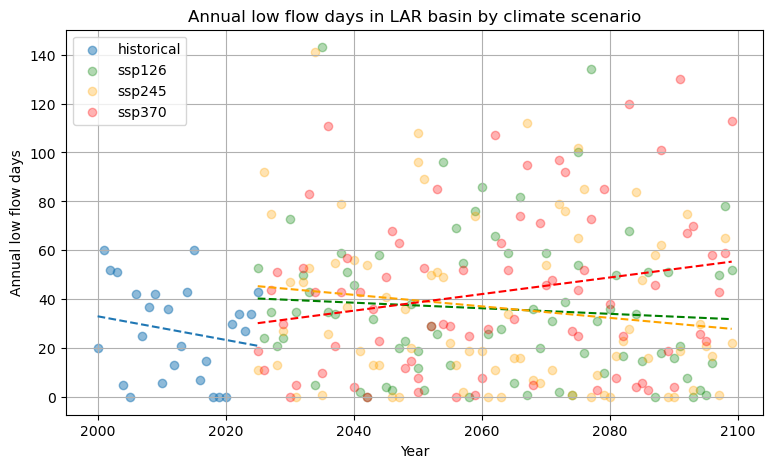

In [27]:
# Show lowflow plot

plot_annual_lowflow_days(
    projection_data=projection_data,
    scenarios=scenarios,
    periods=periods,
    observed_lowflows=observed_lowflows)

**Figure 12:** Annual low flow days and trendline between 2000-2099 under climate scenarios.

In [29]:
# Calculate p values to determine trend statistical significance

def slope_significance(projection_data, observed_lowflows):
    results = []

    # Historical observed period
    x = observed_lowflows["year"].values
    y = observed_lowflows["observed_lowflow_days"].values

    reg = linregress(x, y)

    results.append({
        "scenario": "historical",
        "p_value": reg.pvalue})

    # Future scenarios
    for scenario in scenarios:
        all_years = []
        all_lowflows = []

        for i in range(len(periods[0])):
            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"
            lowflow_table = projection_data[key]["lowflow"]

            all_years.extend(lowflow_table["year"].values)
            all_lowflows.extend(lowflow_table["set_avg"].values)

        reg = linregress(all_years, all_lowflows)

        results.append({
            "scenario": scenario,
            "p_value": reg.pvalue})

    return pd.DataFrame(results)

In [30]:
# Show slope significanc output

slope_results = slope_significance(projection_data=projection_data, observed_lowflows=observed_lowflows)

slope_results

,scenario,p_value
0,historical,0.349174
1,ssp126,0.483318
2,ssp245,0.188232
3,ssp370,0.053621


The significance of the fitted slopes in Figure 12  show p values of 0,48 for SSP126, 0,19 for SSP245 and 0,054 for SSP370. The trends for SSP126 and SSP245 are not statistically significant as p >> 0,05. The trend is clearest for SSP370, where the p value lies very close to 0,05 although still exceeding the threshold. This suggests there is close to significant evidence for a long term increase in low flow days, although year to year variability remains large. This is expected due to the natural climate variability and multi year climate cycles such as El Niño and La Niña. It is also notable that the evidence for a long term trend becomes stronger as the severity of the climate scenario increases. 

Figure 13 shows the cumulative distribution frequency (CDF) of annual low flow days for the observed period and future climate scenarios. The future scenarios shifted upward compared to the observed period, indicating that years with many low flow days become more frequent. This shift is strongest for SSP370, followed by SSP245 and SSP126, suggesting low flow occurrence increases with scenario severity. The observed period does not exceed 60 low flow days, while more than 20% of future years exceed this value. The magnitude of the highest low flow years also increases strongly in the future scenarios with annual total exceeding 100 days in several cases for each scenario. However, these should be interpreted with caution as the CMIP6 validation indicated that extreme years may be overestimated. 


In [31]:
# Create CDF plotting function

def plot_cdf(projection_data, scenarios, periods):

    plt.figure(figsize=(8, 5))

    # Observed CDF
    observed_values = np.sort(observed_lowflows["observed_lowflow_days"].values)
    observed_cdf = np.arange(1, len(observed_values) + 1) / len(observed_values)

    # plt.plot(observed_values,observed_cdf,marker="o",label="Observed 2000-2025")
    plt.plot(observed_cdf, observed_values, marker="o", label="Observed 2000-2025", color=colours["historical"])

    # Scenario CDFs
    for scenario in scenarios:

        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"

            lowflow_table = projection_data[key]["lowflow"]

            all_lowflows.extend(lowflow_table["set_avg"].values)

        values = np.sort(all_lowflows)
        cdf = np.arange(1, len(values) + 1) / len(values)

        plt.plot(cdf,values,marker="o",label=scenario, color=colours[scenario])

    plt.ylabel("Annual low flow days")
    plt.xlabel("Cumulative probability")
    plt.title("CDF of annual low flow days")
    plt.grid(True)
    plt.legend()
    plt.show()

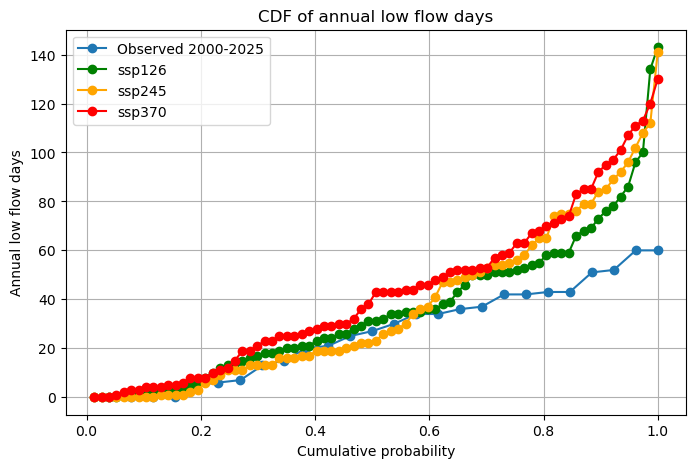

In [32]:
# Show CDF plot

plot_cdf(
    projection_data=projection_data,
    scenarios=scenarios,
    periods=periods)

**Figure 13:** CDF of annual low flow days for the observed period (2000-2025) and future scenarios (2025-2099). 


In [35]:
# Create quantile table function

def lowflow_quantile_table(lowflow_results, scenarios, periods):

    rows = []

    for scenario in scenarios:

        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"
            
            lowflow_table = lowflow_results[key]["lowflow"]

            all_lowflows.extend(lowflow_table["set_avg"].values)

        values = pd.Series(all_lowflows)

        # Append table and define quantiles 
        rows.append({
            "scenario": scenario,
            "mean": round(values.mean(), 1),
            "median": values.median(),
            "p50": values.quantile(0.5),
            "p75": values.quantile(0.75),
            "p90": values.quantile(0.90),
            "max": values.max()})

    return pd.DataFrame(rows)

In [36]:
# Show table
# lowflow_quantile_table(projection_data, scenarios, periods)

Table 6 summarises the distribution of annual low flow days for each future scenario. SSP370 has the highest mean, median, p75 and p90 values, indicating that both typical and relative dry years contain significantly more low flow days under the scenario with the most warming. 

*Table 6: Summary of statistics of annual low flow days for future climate scenarios between 2025-2099.* 

| **Scenario**   | mean  | median | p75  | p90 | max |
|----------------|-------------------------|-----------|------------|-----------|-------|
| SSP126         | 36                      | 31        | 52         | 74        | 143   |
| SSP245         | 37                      | 23        | 56         | 84        | 141   |
| SSP370         | 43                      | 43        | 63         | 93        | 130   |

## 6.2 Seasonal changes in navigational period 

Besides low flow days, the timing of the open water season was re-evaluated for each climate scenario between 2025-2099 and compared to the historical period between 2000-2025. Figure 14 shows the distribution of estimated river break up dates. Compared to the historical period, all future scenarios show a shift toward earlier break up dates. The shift is strongest for SSP370, where break up occurs more frequently in March and early April. 

In [37]:
# Function to calculate break up / freshet dates for every year and scenario

q_critical = 500

def find_breakup_dates(projection_data, start_year_hist, end_year_hist,start_year_fut, end_year_fut):

    freshet_start_dates = []

    for scenario in scenarios_new:

        # Select years and discharge data depending on scenario
        if scenario == "historical":

            start_year_use = start_year_hist
            end_year_use = end_year_hist

            discharge_data = q_obs.copy()
            discharge_data["Year"] = discharge_data["Date"].dt.year
            
            discharge_col = "discharge_m3s"

        else:

            start_year_use = start_year_fut
            end_year_use = end_year_fut

            discharge_data_list = []

            for i in range(len(periods[0])):

                start_year = periods[0][i]
                end_year = periods[1][i]

                key = f"{scenario}_{start_year}_{end_year}"

                period_data = projection_data[key]["ensemble"].copy()

                period_data["Date"] = pd.to_datetime(period_data.index)
                period_data["Year"] = period_data["Date"].dt.year

                discharge_data_list.append(period_data)

            discharge_data = pd.concat(discharge_data_list)
            discharge_data = discharge_data.drop_duplicates(subset="Date", keep="first")
            discharge_data = discharge_data.sort_values("Date")

            discharge_col = "Mean"

        # Loop through every year
        for year in range(start_year_use, end_year_use + 1):

            # Select data after March 1
            season_data = discharge_data[
                (discharge_data["Year"] == year) &
                (discharge_data["Date"] >= pd.to_datetime(f"{year}-03-01"))]

            # Identify first day where q > q_critical
            above_critical = season_data[
                season_data[discharge_col] > q_critical]

            if len(above_critical) > 0:

                first_day = above_critical.iloc[0]

                freshet_start_dates.append({
                    "scenario": scenario,
                    "year": year,
                    "freshet_start_date": first_day["Date"],
                    "discharge_m3s": first_day[discharge_col]})

    freshet_start_dates = pd.DataFrame(freshet_start_dates)

    return freshet_start_dates

In [38]:
# Run function

breakup_start_dates = find_breakup_dates(
    projection_data=projection_data,
    start_year_hist=2000,
    end_year_hist=2025,
    start_year_fut=2025,
    end_year_fut=2099)

In [39]:
# Function to plot results on a barchart

def plot_freshet_barchart_10day(freshet_dates, title, colname):

    data = freshet_dates.copy()

    # Convert freshet start date to day-of-year
    data["doy"] = data[colname].dt.dayofyear

    # Define 10-day bins
    min_doy = int(data["doy"].min())
    max_doy = int(data["doy"].max())

    bins = np.arange(min_doy, max_doy + 10, 10)

    data["date_bin"] = pd.cut(data["doy"], bins=bins, right=False)

    # Count number of freshet dates per scenario per bin
    count_table = (data.groupby(["date_bin", "scenario"]).size().reset_index(name="count"))

    # Create readable labels for bins
    bin_labels = []

    for interval in count_table["date_bin"].cat.categories:
        start_date = pd.Timestamp("2000-01-01") + pd.Timedelta(days=int(interval.left) - 1)
        end_date   = pd.Timestamp("2000-01-01") + pd.Timedelta(days=int(interval.right) - 2)

        label = f"{start_date.strftime('%b %d')}-{end_date.strftime('%b %d')}"
        bin_labels.append(label)

    label_map = dict(zip(count_table["date_bin"].cat.categories, bin_labels))
    
    count_table["date_bin_label"] = count_table["date_bin"].map(label_map)

    # Pivot for plotting
    plot_table = count_table.pivot_table(index="date_bin_label", columns="scenario", values="count", fill_value=0)

    # Remove bins where all scenarios have zero observations
    plot_table = plot_table.loc[plot_table.sum(axis=1) > 0]

    # Plot
    plot_table.plot(kind="bar", figsize=(10, 5), color=[colours[scenario] for scenario in plot_table.columns])

    plt.xlabel(f"{title} date range")
    plt.ylabel("Number of years")
    plt.title(f"Distribution of {title} dates by climate scenario")
    plt.grid(axis="y")
    plt.legend(title="Scenario")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(range(0, int(plot_table.to_numpy().max()) + 1, 3))

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_232300/1249854821.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_232300/1249854821.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


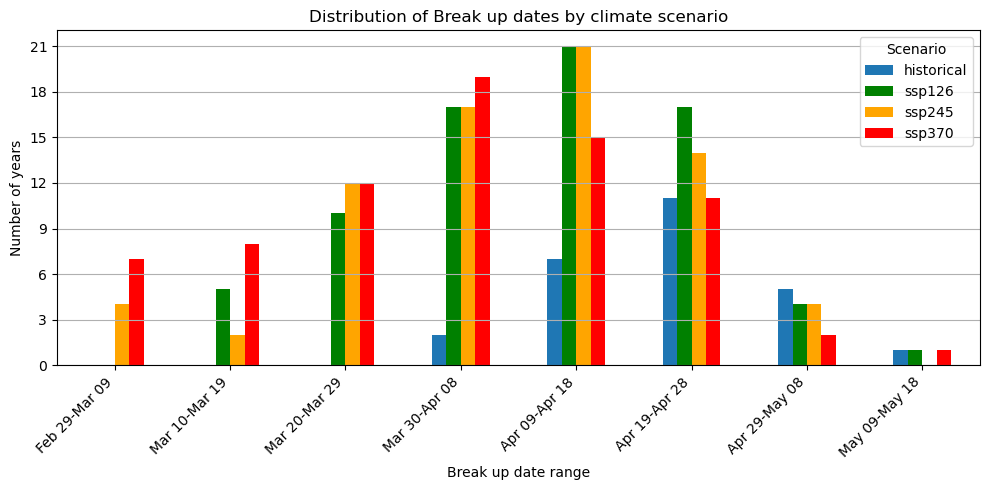

In [40]:
plot_freshet_barchart_10day(freshet_dates=breakup_start_dates, colname="freshet_start_date", title="Break up")

**Figure 14:** Timing of river ice break up dates for historical period 2000-2025 and climate scenarios 2025-2099. 

Figure 15 shows the distribution of estimated freeze up dates. The future scenarios show a shift toward later freeze up dates compared to the historical period. This indicated that the open water season becomes longer under future climate scenarios. Again, this shift is strongest for SSP370, where freeze up occurs more frequently in middle to late November with outliers in December. 

### Extract & prepare forcing data for freeze up calculation

In [42]:
# Define vars for extraction

var_names = {"evspsblpot", "pr", "rsds", "tas"}

forcing_data = {}
annual_avg = []
period_avg = []

for scenario in scenarios:

    forcing_data[scenario] = {}

    for var_name in var_names:

        merged_data_list = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            # Define file path
            forcing_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}" / f"combined_CMIP6_{start_year}_{end_year}_{var_name}.nc"
            
            # Load file as dataset
            ds = xr.open_dataset(forcing_file)

            # Load file as array
            da = ds[var_name]

            # Convert to series 
            series = pd.Series(data=da.values.squeeze(),index=pd.to_datetime(da["time"].values).normalize(),name=var_name)

            # Convert pr and evap from km^2/s to mm^2/day
            if var_name in ["pr", "evspsblpot"]:
                series = series * 86400
                annual = series.groupby(series.index.year).sum()

            # Convert temp from Kelvin to Celcius
            elif var_name == "tas":
                series = series - 273.15
                annual = series.groupby(series.index.year).mean()

            elif var_name == "rsds":
                annual = series.groupby(series.index.year).mean()

            # Save for merged time series
            merged_data_list.append(series)

            # Save annual values
            for year, annual_value in annual.items():

                annual_avg.append({
                    "scenario": scenario,
                    "period": f"{start_year}-{end_year}",
                    "year": year,
                    "variable": var_name,
                    "value": annual_value})

            # Save 25 year average
            period_avg.append({
                "scenario": scenario,
                "period": f"{start_year}-{end_year}",
                "variable": var_name,
                "value": annual.mean()})

        # Merge periods into one 2025–2099 series
        merged_data = pd.concat(merged_data_list)
        merged_data = merged_data[~merged_data.index.duplicated(keep="first")]
        merged_data = merged_data.sort_index()

        forcing_data[scenario][var_name] = merged_data

# Create summary table for annual avg values
annual_table = pd.DataFrame(annual_avg)

# Create summary table for period avg values
period_table = pd.DataFrame(period_avg).pivot_table(index=["scenario", "period"],columns="variable",values="value")

In [43]:
# Prepare historical data

def load_hist(start_year, end_year):

    forcing_data_hist = {}
    scenario = "historical"
    forcing_data_hist[scenario] = {}
    annual_avg = []

    for var_name in var_names:

        merged_data_list = []
    
        forcing_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}" / f"combined_CMIP6_{start_year}_{end_year}_{var_name}.nc"

        # Load file as dataset
        ds = xr.open_dataset(forcing_file)

        # Load file as array
        da = ds[var_name]

        # Convert to series 
        series = pd.Series(data=da.values.squeeze(),index=pd.to_datetime(da["time"].values).normalize(),name=var_name)

        # Convert pr and evap from km^2/s to mm^2/day
        if var_name in ["pr", "evspsblpot"]:
            series = series * 86400
            annual = series.groupby(series.index.year).sum()

        # Convert temp from Kelvin to Celcius
        elif var_name == "tas":
            series = series - 273.15
            annual = series.groupby(series.index.year).mean()

        elif var_name == "rsds":
            annual = series.groupby(series.index.year).mean()

        # Save for merged time series
        merged_data_list.append(series)

        # Save annual values
        for year, annual_value in annual.items():

            annual_avg.append({
                "scenario": scenario,
                "period": f"{start_year}-{end_year}",
                "year": year,
                "variable": var_name,
                "value": annual_value})

        # Merge period into one series
        merged_data = pd.concat(merged_data_list)
        merged_data = merged_data[~merged_data.index.duplicated(keep="first")]
        merged_data = merged_data.sort_index()

        forcing_data_hist[scenario][var_name] = merged_data
            
    annual_hist_table = pd.DataFrame(annual_avg)
    
    return annual_hist_table, forcing_data_hist

In [44]:
# Run function

annual_hist_table, forcing_data_hist = load_hist(start_year=1989,end_year=2014)

In [45]:
# Merge forcing data (useful for freeze up calculation)

forcing_data_all = forcing_data.copy()

forcing_data_all["historical"] = forcing_data_hist["historical"]

### Calculate freeze up dates

In [46]:
# Function to calculate freeze up dates for every year and scenario

AFDD_critical = 30

def find_freezeup_dates(forcing_data, start_year_fut, end_year_fut, start_year_hist, end_year_hist):

    AFDD_critical_dates = []

    for scenario in scenarios_new:

        # Extract temperature above surface (tas) data
        temp_data = forcing_data_all[scenario]["tas"]

        # Convert into df to make life easier
        temp_data = pd.DataFrame({"Date": temp_data.index, "Temp": temp_data.values})

        # Conver to datetime
        temp_data["Date"] = pd.to_datetime(temp_data["Date"])

        # Assign year to each data point
        temp_data["Year"] = temp_data["Date"].dt.year

        if scenario == "historical":
            
            start_year_use = start_year_hist
            end_year_use = end_year_hist

        else:

            start_year_use = start_year_fut
            end_year_use = end_year_fut
    
        # Loop through every year
        for year in range(start_year_use, end_year_use + 1):

            # Start counting from October 1 to eliminate anomalies
            year_data = temp_data[
                (temp_data["Year"] == year) &
                (temp_data["Date"] >= pd.to_datetime(f"{year}-10-01"))]

            # Set 0 as starting point for counting cumulative
            AFDD = 0

            # Loop through all data points in a year
            for i in range(len(year_data)):

                temp = year_data.iloc[i]["Temp"]
                date = year_data.iloc[i]["Date"]

                # Cumulative AFDD
                if temp < 0:
                    AFDD += -temp

                # Append when AFDD is critical
                if AFDD >= AFDD_critical:

                    AFDD_critical_dates.append({
                        "scenario": scenario,
                        "year": year,
                        "AFDD_critical_date": date,
                        "AFDD": AFDD,
                        "Temp": temp})
                    
                    break

    AFDD_critical_dates = pd.DataFrame(AFDD_critical_dates)

    return AFDD_critical_dates

In [47]:
# Run function

freezeup_dates_future = find_freezeup_dates(
    forcing_data=forcing_data,
    start_year_fut=2025,
    end_year_fut=2099,
    start_year_hist=1989,
    end_year_hist=2014)

/tmp/ipykernel_232300/1249854821.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_232300/1249854821.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


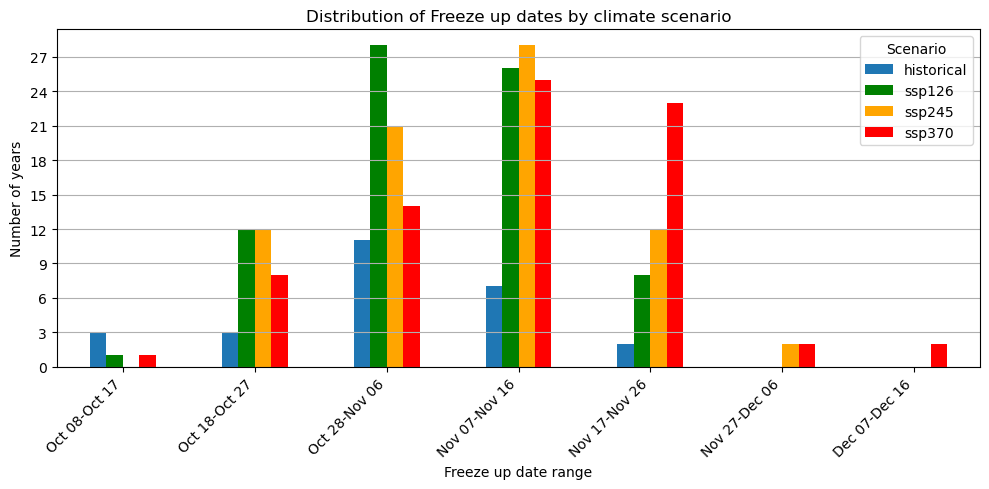

In [48]:
# Call barchart function

plot_freshet_barchart_10day(freshet_dates=freezeup_dates_future, colname="AFDD_critical_date", title="Freeze up")

**Figure 15:** Timing of river freeze up dates for historical period 2000-2025 and climate scenarios 2025-2099. 

Overall, the results indicate an expansion of the open water navigational season where under all climate scenarios, ice breaks up earlier and freezes up later compared to the historical period.